# 📊 エリア別・商品カテゴリ別 返品率

エリア（州）と商品カテゴリの組み合わせごとに返品率をヒートマップで表示する。
注文件数5件未満のセルはデータ不足として非表示にしている。

> ※ 本notebookはローカルモジュール（`Lv01_03_configuration`）に依存しているため、単体での実行はできません。分析の流れとアウトプットの確認を目的としています。

In [ ]:
# ================================================ #
# imports
# ================================================ #

# 標準ライブラリ
import sys
from pathlib import Path

# 外部ライブラリ
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from IPython.display import display

# ローカルモジュール
%load_ext autoreload
%autoreload 2
sys.path.insert(0, str(Path.cwd().parents[1]))
sys.path.insert(0, str(Path.cwd().parents[2]))
from Lv01_03_configuration.cnfg_b_dir_01_local import DIRS
from Lv01_03_configuration.cnfg_d_proc_01_merged import Proc01info, Cols, Items
from Lv01_03_configuration.cnfg_u_local_02_function import generate_dic_ym_to_fiscal_quarter
from Lv01_03_configuration.cnfg_p_chart import generate_chart_heatmap_return_rate
from Lv01_03_configuration.cnfg_a_api_01_pub import (
    pmod_01_loading_df as func_loading_df,
    pmod_20_formatting_datetime as func_datetime_format,
)

In [ ]:
# ================================================ #
# データ読み込み・加工
# ================================================ #

# データ読み込み
df = func_loading_df.read_as_dataframe_from_excel_or_csv(
    target_file_path=Path(DIRS.Processed) / Proc01info.FILENAME
)

# 年月カラムの追加
df = (
    df.copy()
    .pipe(
        func_datetime_format.format_ss_half_y4m2,
        target_col        = Cols.order_date,
        output_col        = Cols.order_ym,
        trans_to_datetime = True
    )
)

# 集計期間の設定
fiscal_start_month = 1
start_year         = 2025
start_month        = 1
end_year           = start_year
end_month          = 12

dic_current_quarter = generate_dic_ym_to_fiscal_quarter(
    fiscal_start_month = fiscal_start_month,
    start_year         = start_year,
    start_month        = start_month,
    end_year           = end_year,
    end_month          = end_month
)
current_list_full = list(dic_current_quarter)
current_list      = current_list_full[:7]

current_df = (
    df.loc[df[Cols.order_ym].isin(current_list)]
    .copy()
    .reset_index(drop=True)
)

# エリア×州のリスト生成
current_df["region_province"] = current_df[Cols.region] + "_" + current_df[Cols.state_province]

region_state_list = (
    current_df
    .drop_duplicates([Cols.region, "region_province"])
    .assign(large_order=lambda x: x[Cols.region].map({v: i for i, v in enumerate(Items.list_region)}))
    .sort_values(["large_order", "region_province"])
    ["region_province"]
    .tolist()
)

# サブカテゴリのリスト生成
sub_category_list = (
    current_df
    .drop_duplicates([Cols.category, Cols.sub_category])
    .assign(large_order=lambda x: x[Cols.category].map({v: i for i, v in enumerate(Items.list_product_category)}))
    .sort_values(["large_order", Cols.sub_category])
    [Cols.sub_category]
    .tolist()
)

x_axis_col       = Cols.sub_category
x_axis_item_list = sub_category_list
y_axis_col       = "region_province"
y_axis_item_list = region_state_list

# サブカテゴリの日本語マッピング
dic_sub_category_jp = {
    "Appliances" : "家電・事務機器",
    "Art"        : "画材",
    "Binders"    : "バインダー",
    "Envelopes"  : "封筒",
    "Fasteners"  : "留め具",
    "Labels"     : "ラベル",
    "Paper"      : "用紙",
    "Storage"    : "収納",
    "Supplies"   : "消耗品",
    "Bookcases"  : "本棚",
    "Chairs"     : "椅子",
    "Furnishings": "インテリア",
    "Tables"     : "テーブル",
    "Accessories": "アクセサリ",
    "Copiers"    : "コピー機",
    "Machines"   : "機器",
    "Phones"     : "電話機",
}

# 分母（全注文数）の集計
col_denominator = "count_all"
col_numerator   = "count_yes"
col_agg         = "rate"
min_denominator = 5

df_denominator = (
    current_df
    .groupby([x_axis_col, y_axis_col], observed=False)
    .size()
    .reset_index(name=col_denominator)
)
df_denominator.loc[df_denominator[col_denominator] < min_denominator, col_denominator] = pd.NA

# 分子（返品数）の集計
df_numerator = (
    current_df[current_df[Cols.returned] == "Yes"].copy()
    .groupby([x_axis_col, y_axis_col], observed=False)
    .size()
    .reset_index(name=col_numerator)
)

# 返品率の計算
df_agg = pd.merge(df_denominator, df_numerator, on=[x_axis_col, y_axis_col], how="left")
df_agg = df_agg.dropna(subset=[col_numerator]).copy()
df_agg[col_agg] = df_agg[col_numerator] / df_agg[col_denominator]

# ヒートマップ用ピボット
df_heatmap = (
    df_agg
    .pivot(index=y_axis_col, columns=x_axis_col, values=col_agg)
    .reindex(index=list(y_axis_item_list), columns=list(x_axis_item_list))
)
df_heatmap = df_heatmap.dropna(axis=0, how="all")
df_heatmap = df_heatmap.dropna(axis=1, how="all")


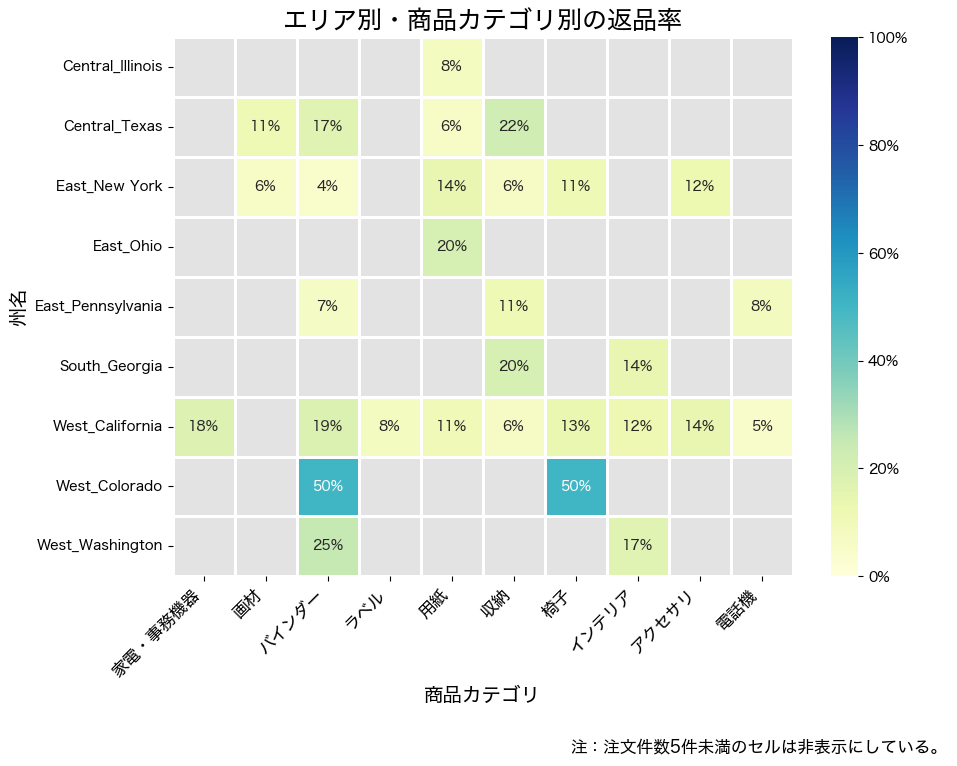

In [3]:
# ================================================ #
# チャート生成
# ================================================ #

plt.rcParams['font.family'] = 'Hiragino Sans'
fig, ax = plt.subplots(figsize=(10, 7))

generate_chart_heatmap_return_rate(
    df_heatmap          = df_heatmap,
    ax                  = ax,
    dic_sub_category_jp = dic_sub_category_jp,
    title               = "エリア別・商品カテゴリ別の返品率",
)

plt.show()